In [26]:
!pip install -q huggingface-hub

In [31]:
from huggingface_hub import notebook_login
notebook_login()

In [1]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [2]:
!pip install wikipedia-api
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from collections import Counter
from keras.saving import register_keras_serializable
import re
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import top_k_categorical_accuracy
nltk.download("punkt_tab")
nltk.download("stopwords")

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=1e121772fa7b9f5e3b0b6c48eaf8487dcb18a79cca013fc6b99b49b1cb7b9602
  Stored in directory: /root/.cache/pip/wheels/33/3c/79/b36253689d838af4a0539782853ac3cc38a83a6591ad570dde
Successfully built wikipedia-api


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# List of dataset files to merge
files = [
    "/content/booster.csv",
    "/content/dataset.csv",
    "/content/booster2.csv"
]
# Load and concatenate all datasets
df_list = [pd.read_csv(f) for f in files]
ds = pd.concat(df_list, ignore_index=True)

# Cleaning and normalization
encoder = LabelEncoder()
ds['label'] = ds['label'].astype(str).str.strip()
df = ds[ds['label'].str.lower() != "label"].copy()
df['label'] = df['label'].replace({'Behaviour': 'Behavior'})
df['label'] = df['label'].str.strip().str.capitalize()

# Remove only problematic labels, not full rows
df = df[~df['label'].str.strip().str.lower().isin(["hardnegative", "nan"])]
# Encode
Y = encoder.fit_transform(df['label'])
print("Final dataset shape:", df.shape)
print("Unique labels:", df['label'].unique())

Final dataset shape: (44590, 2)
Unique labels: ['Feature' 'Genus' 'Roleinecosystem' 'Diet' 'Behavior' 'Habitat' 'Gpe'
 'Adaptation' 'Timeperiod' 'Threat']


In [4]:
df

,name,label
0,bioluminescence,Feature
1,acropora,Genus
2,scavenger,Roleinecosystem
3,fish eater,Diet
4,thunnus,Genus
...,...,...
46450,submitting,Behavior
46451,excellent swimmer,Adaptation
46452,specialized digestive system,Feature
46453,frugivore,Diet


In [5]:
df['label'].unique()

array(['Feature', 'Genus', 'Roleinecosystem', 'Diet', 'Behavior',
       'Habitat', 'Gpe', 'Adaptation', 'Timeperiod', 'Threat'],
      dtype=object)

In [6]:
class_counts = df['label'].value_counts()
print(class_counts[class_counts < 2])

Series([], Name: count, dtype: int64)


In [7]:
df['label'].value_counts()

,count
label,
Behavior,6180
Adaptation,6141
Feature,5723
Diet,4913
Roleinecosystem,4299
Habitat,3930
Genus,3794
Threat,3615
Gpe,3529


In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y),
    y=Y
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.7261032405145742), 1: np.float64(0.7215210355987055), 2: np.float64(0.9075921025849786), 3: np.float64(0.7791368163550585), 4: np.float64(1.1752767527675276), 5: np.float64(1.2635307452536129), 6: np.float64(1.1346055979643765), 7: np.float64(1.0372179576645733), 8: np.float64(1.2334716459197788), 9: np.float64(1.808191403081914)}


In [9]:
import tensorflow as tf
from tensorflow.keras import layers

input_dim = 384   # your embedding size
num_classes = len(encoder.classes_)  # total unique labels

inp = layers.Input(shape=(input_dim,), name="input")

# Dense block 1
x = layers.Dense(512, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Dense block 2
x = layers.Dense(256, activation="gelu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Residual connection (skip from input to deeper layer)
res = layers.Dense(256, activation="relu")(inp)
x = layers.Add()([x, res])

# Dense block 3
x = layers.Dense(128, activation="gelu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

# Output layer (softmax for classification)
out = layers.Dense(num_classes, activation="softmax")(x)

ANN = tf.keras.Model(inputs=inp, outputs=out, name="Dense_Residual_Classifier")

ANN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

ANN.summary()

Model: "Dense_Residual_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 384)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    197,120 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     98,560 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │      1,290 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 464,778 (1.77 MB)

 Trainable params: 462,986 (1.77 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [10]:
from tensorflow.keras.utils import register_keras_serializable
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW

@register_keras_serializable(package="Custom", name="WarmUpLearningRate")
class WarmUpLearningRate(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, decay_schedule_fn):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.decay_schedule_fn = decay_schedule_fn
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.initial_lr * (step / tf.cast(self.warmup_steps, tf.float32))
        return tf.cond(
            step < self.warmup_steps,
            lambda: warmup_lr,
            lambda: self.decay_schedule_fn(step - self.warmup_steps)
        )
    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "decay_schedule_fn": tf.keras.optimizers.schedules.serialize(self.decay_schedule_fn),
        }
    @classmethod
    def from_config(cls, config):
        config["decay_schedule_fn"] = tf.keras.optimizers.schedules.deserialize(config["decay_schedule_fn"])
        return cls(**config)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights= True
)
checkpoint_filepath = 'NER_Model.weights.h5'
model_checkp = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_best_only=True,
    save_weights_only=True  # important if using .h5
)
decay_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    end_learning_rate=1e-5,
    power=1.05
)
warmup_lr = WarmUpLearningRate(
    initial_lr=0.001,
    warmup_steps=1000,
    decay_schedule_fn=decay_schedule
)
optimizer = AdamW(
    learning_rate=warmup_lr,
    weight_decay=1e-4
)
loss = tf.keras.losses.SparseCategoricalCrossentropy()
ANN.compile(
    optimizer = optimizer,
    loss = loss ,
    metrics=['accuracy']
)

In [11]:
ANN.summary()

Model: "Dense_Residual_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 384)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    197,120 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     98,560 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │      1,290 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 464,778 (1.77 MB)

 Trainable params: 462,986 (1.77 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df['name'],Y, test_size=0.3, random_state=42, stratify= Y)
X_train_embeddings = model.encode(X_train.tolist(), show_progress_bar=True)
X_test_embeddings = model.encode(X_test.tolist(), show_progress_bar=True)
history = ANN.fit(X_train_embeddings, y_train, epochs=40, batch_size= 128, validation_split=0.2,callbacks = [early_stop, model_checkp],class_weight = class_weights)
y_pred_probs = ANN.predict(X_test_embeddings)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test,y_pred,labels=range(len(encoder.classes_)),target_names=encoder.classes_,zero_division = 0))

Batches:   0%|          | 0/976 [00:00<?, ?it/s]

Batches:   0%|          | 0/419 [00:00<?, ?it/s]

Epoch 1/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.1735 - loss: 2.7192 - val_accuracy: 0.1908 - val_loss: 2.2106
Epoch 2/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6155 - loss: 1.0576 - val_accuracy: 0.6998 - val_loss: 1.2874
Epoch 3/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7417 - loss: 0.6821 - val_accuracy: 0.8140 - val_loss: 0.5669
Epoch 4/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7876 - loss: 0.5345 - val_accuracy: 0.8325 - val_loss: 0.4465
Epoch 5/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8160 - loss: 0.4603 - val_accuracy: 0.8424 - val_loss: 0.4283
Epoch 6/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8313 - loss: 0.4083 - val_accuracy: 0.8541 - val_loss: 0.3973
Epoch 7/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8419 - loss: 0.3754 - val_accuracy: 0.8550 - val_loss: 0.3832
Epoch 8/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8425 - loss: 0.3648 - val_accuracy:

In [49]:
print("X_train_embeddings shape:", X_train_embeddings.shape)
print("y_train shape:", y_train.shape)
print("First few y_train values:", y_train[:10])

X_train_embeddings shape: (29903, 384)
y_train shape: (29903,)
First few y_train values: [3 8 8 1 8 1 8 7 4 0]


In [50]:
encoder.classes_

array(['Adaptation', 'Behavior', 'Diet', 'Feature', 'Genus', 'Gpe',
       'Habitat', 'Roleinecosystem', 'Threat', 'Timeperiod'], dtype=object)

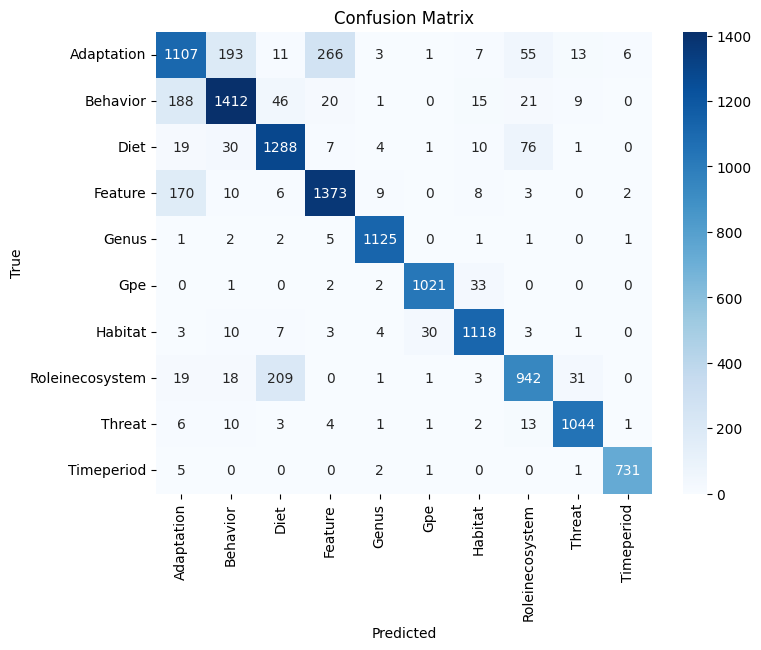

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels= encoder.classes_, yticklabels= encoder.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("conf_mat.png")
plt.title("Confusion Matrix")
plt.show()

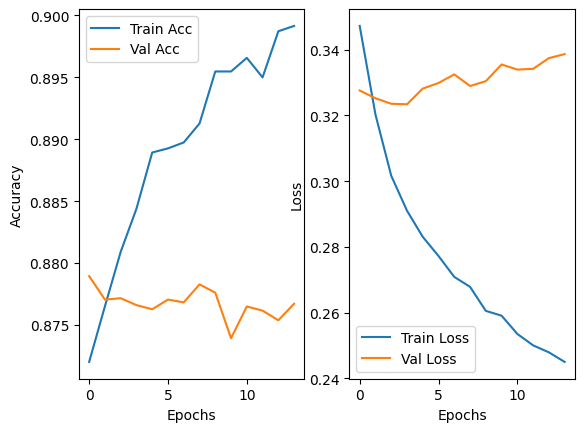

In [ ]:
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
ANN = tf.keras.models.load_model('/content/NER_Model.keras')

In [ ]:
print("Train embeddings:", X_train_embeddings.shape)
print("Test embeddings:", X_test_embeddings.shape)
y_pred_probs = ANN.predict(X_test_embeddings)
print("y_pred_probs shape:", y_pred_probs.shape)

Train embeddings: (32039, 384)
Test embeddings: (10680, 384)
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
y_pred_probs shape: (10680, 10)


In [ ]:
encoder.classes_

In [ ]:
def classify_text(text, embedder, ann_model, encoder):
    words = re.findall(r'\b\w+\b', text.lower())
    label_counts = Counter()
    for word in words:
        embedding = embedder.encode([word])
        probs = ann_model.predict(embedding, verbose=0)[0]
        label_idx = np.argmax(probs)
        label = encoder.classes_[label_idx]
        label_counts[label] += 1
    final_label = label_counts.most_common(1)[0][0] if label_counts else "Unknown"
    return final_label, dict(label_counts)
def predict_word(word, embedder, ann_model, encoder, top_k=3):
    embedding = embedder.encode([word])
    probs = ann_model.predict(embedding)[0]
    top_k_indices = np.argsort(probs)[::-1][:top_k]
    results = {encoder.classes_[i]: float(probs[i]) for i in top_k_indices}
    return results
unseen_words = ["forest", "lion", "Africa", "herbivore", "Jurassic"]
for word in unseen_words:
    predictions = predict_word(word, model, ANN, encoder, top_k=3)
    print(f"\nWord: {word}")
    for label, prob in predictions.items():
        print(f"  {label}: {prob:.4f}")
sample_text = "Tigers are carnivores found in dense forests and grasslands of Asia."
label, counts = classify_text(sample_text, model, ANN, encoder)
print("Text:", sample_text)
print("Predicted Label:", label)
print("Label Counts:", counts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step

Word: forest
  Habitat: 0.9969
  Gpe: 0.0030
  Threat: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Word: lion
  Genus: 0.9089
  Roleinecosystem: 0.0653
  Diet: 0.0146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Word: Africa
  Gpe: 1.0000
  Habitat: 0.0000
  Genus: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Word: herbivore
  Diet: 0.4881
  Roleinecosystem: 0.4709
  Behavior: 0.0357
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Word: Jurassic
  Timeperiod: 1.0000
  Genus: 0.0000
  Gpe: 0.0000
Text: Tigers are carnivores found in dense forests and grasslands of Asia.
Predicted Label: Habitat
Label Counts: {'Genus': 1, 'Behavior': 1, 'Roleinecosystem': 1, 'Feature': 2, 'Habitat': 5, 'Gpe': 1}


In [ ]:
import wikipediaapi
animal_name = "Tiger"
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='MyWikiApp/1.0 (https://github.com/myusername/myrepo; myemail@example.com)'
)
page = wiki.page(animal_name)
summary_sentences = page.summary.split(". ")

In [ ]:
summary_sentences

['The tiger (Panthera tigris) is a large cat and a member of the genus Panthera native to Asia',
 'It has a powerful, muscular body with a large head and paws, a long tail and orange fur with black, mostly vertical stripes',
 "It is traditionally classified into nine recent subspecies, though some recognise only two subspecies, mainland Asian tigers and the island tigers of the Sunda Islands.\nThroughout the tiger's range, it inhabits mainly forests, from coniferous and temperate broadleaf and mixed forests in the Russian Far East and Northeast China to tropical and subtropical moist broadleaf forests on the Indian subcontinent and Southeast Asia",
 'The tiger is an apex predator and preys mainly on ungulates, which it takes by ambush',
 'It lives a mostly solitary life and occupies home ranges, defending these from individuals of the same sex',
 'The range of a male tiger overlaps with that of multiple females with whom he mates',
 'Females give birth to usually two or three cubs that

In [ ]:
def sentence_to_embedding(sentence, model, embedding_dim=384):
    words = nltk.word_tokenize(sentence)
    stop = nltk.corpus.stopwords.words('english')
    words = [word for word in words if word.lower() not in stop and word.isalnum()]
    if not words:
        return np.zeros((1, embedding_dim))
    embeddings = model.encode(words)
    if embeddings.ndim == 1:  # single vector
        embeddings = embeddings[np.newaxis, :]
    mean_embedding = embeddings.mean(axis=0)
    return mean_embedding.reshape(1, -1)

# Prediction
sentence = summary_sentences[10]
embedding = sentence_to_embedding(sentence, model)
pred = ANN.predict(embedding)
pred_label_idx = np.argmax(pred, axis=1)
pred_label = encoder.inverse_transform(pred_label_idx)[0]
pred_label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


'Roleinecosystem'

In [ ]:
encoder.classes_

array(['Adaptation', 'Behavior', 'Diet', 'Feature', 'Genus', 'Gpe',
       'Habitat', 'Roleinecosystem', 'Threat', 'Timeperiod'], dtype=object)

In [ ]:
sentence

'Major threats to tigers are habitat destruction and fragmentation due to deforestation, poaching for fur and the illegal trade of body parts for medicinal purposes'

In [ ]:
df[df['label'] == 'Threat']

,name,label
46,pollution,Threat
52,illegal fishing,Threat
65,ocean deoxygenation,Threat
102,illegal wildlife trade,Threat
109,coral bleaching,Threat
...,...,...
44548,viral diseases,Threat
44549,asian hornets,Threat
44566,noise pollution,Threat
44576,invasive species,Threat
